In [1]:
# Install required spatial libraries
!pip install -q scanpy squidpy igraph leidenalg scikit-image dask spatialdata spatialdata-io spatialdata-plot seaborn

# Download the official Xenium Human Lung test dataset from 10x Genomics
!curl -O https://cf.10xgenomics.com/samples/xenium/2.0.0/Xenium_V1_human_Lung_2fov/Xenium_V1_human_Lung_2fov_outs.zip

# Extract it into a folder named Xenium
!unzip -q -o Xenium_V1_human_Lung_2fov_outs.zip -d Xenium

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.2/199.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 7.7 MB/s eta 

In [2]:
# Import core packages
import spatialdata as sd
import spatialdata_plot
from spatialdata_io import xenium
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import seaborn as sns

# Load raw Xenium data, save to Zarr, and read back
xenium_path = "./Xenium"
zarr_path = "./Xenium.zarr"
sdata_raw = xenium(xenium_path, cells_as_circles=True)
sdata_raw.write(zarr_path)

# Extract the AnnData object containing expression and spatial coordinates
sdata = sd.read_zarr(zarr_path)
adata = sdata.tables["table"]

/usr/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/usr/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/usr/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/usr/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/usr/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/usr/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/usr/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(se

Negative DNA probe %: 0.00
Negative decoding %:  0.01


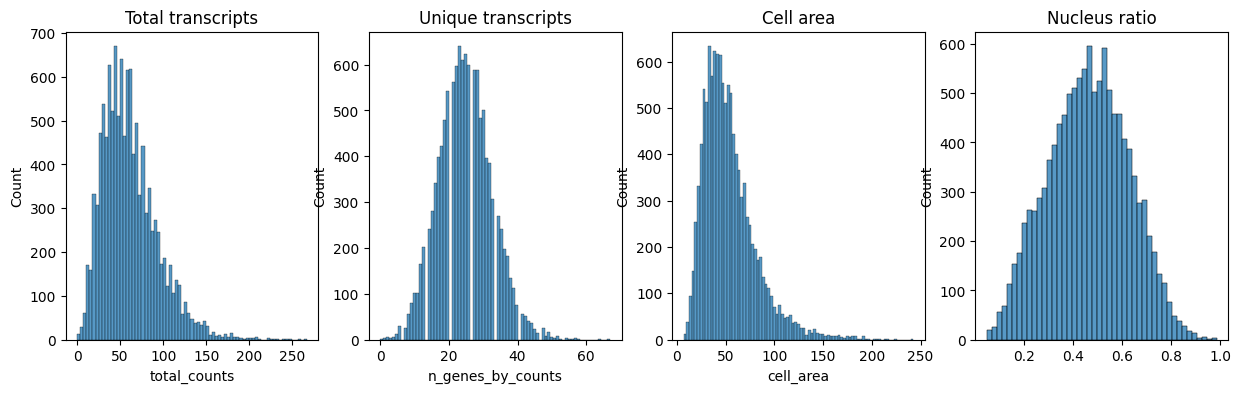

In [3]:
# Calculate basic QC metrics in place
sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

# Calculate percentage of total counts from negative controls
cprobes = adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
cwords  = adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100

print(f"Negative DNA probe %: {cprobes:.2f}")
print(f"Negative decoding %:  {cwords:.2f}")

# Plot transcripts, genes, cell area, and nucleus ratio
fig, axs = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(adata.obs["total_counts"], kde=False, ax=axs[0]).set_title("Total transcripts")
sns.histplot(adata.obs["n_genes_by_counts"], kde=False, ax=axs[1]).set_title("Unique transcripts")
sns.histplot(adata.obs["cell_area"], kde=False, ax=axs[2]).set_title("Cell area")
sns.histplot(adata.obs["nucleus_area"] / adata.obs["cell_area"], kde=False, ax=axs[3]).set_title("Nucleus ratio")
plt.savefig("xenium_qc_histograms.png", bbox_inches="tight", dpi=300)
plt.show()

In [4]:
# Remove cells with too few counts and genes found in too few cells
sc.pp.filter_cells(adata, min_counts=10)
sc.pp.filter_genes(adata, min_cells=5)

In [5]:
# Keep raw counts, normalize, and log transform
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

# Find highly variable genes and run PCA
sc.pp.highly_variable_genes(adata)
sc.pp.pca(adata)

# Build neighbor graph in PCA space and generate Leiden clusters
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, flavor="igraph", directed=False, n_iterations=2)

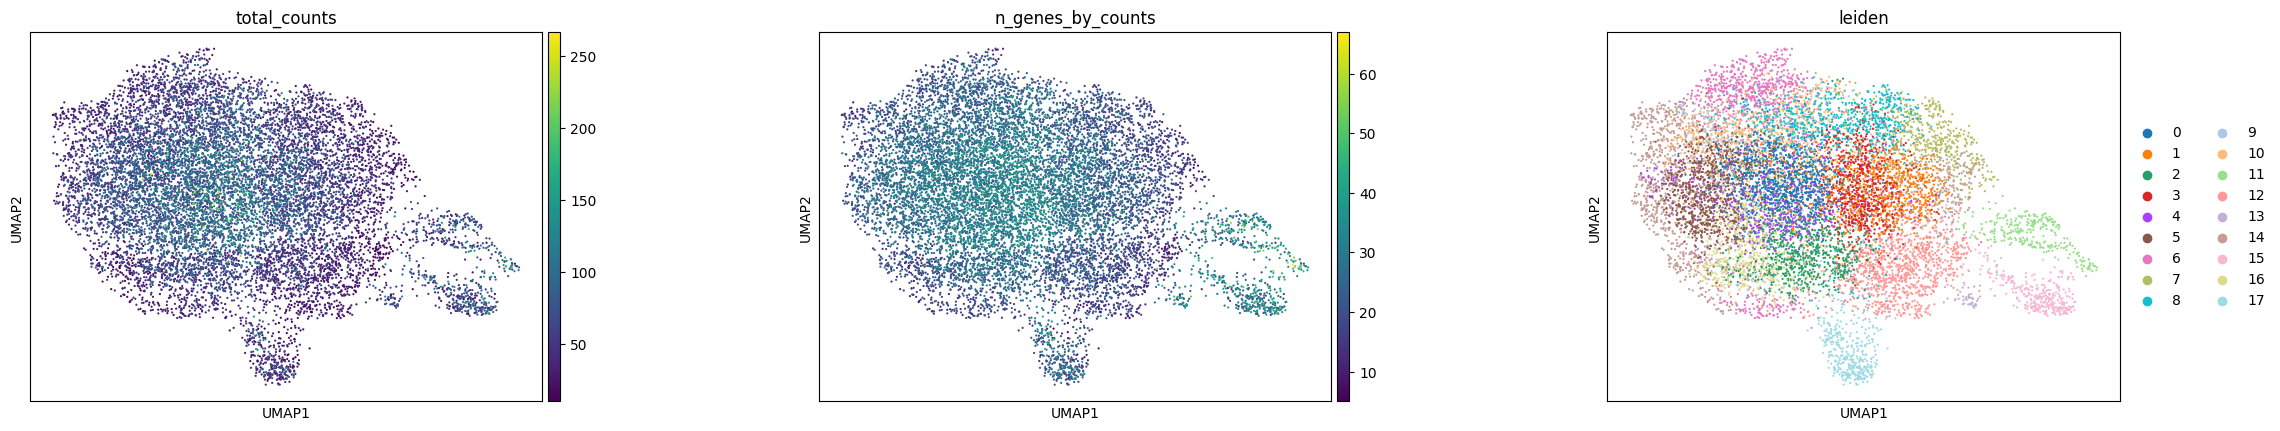

In [6]:
# Plot UMAP colored by QC metrics and Leiden clusters
sc.pl.umap(
    adata,
    color=["total_counts", "n_genes_by_counts", "leiden"],
    wspace=0.4,
    show=False
)
plt.savefig("xenium_umap_clusters.png", bbox_inches="tight", dpi=300)
plt.show()

In [7]:
# Connect each cell to nearest spatial neighbors using Delaunay triangulation
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


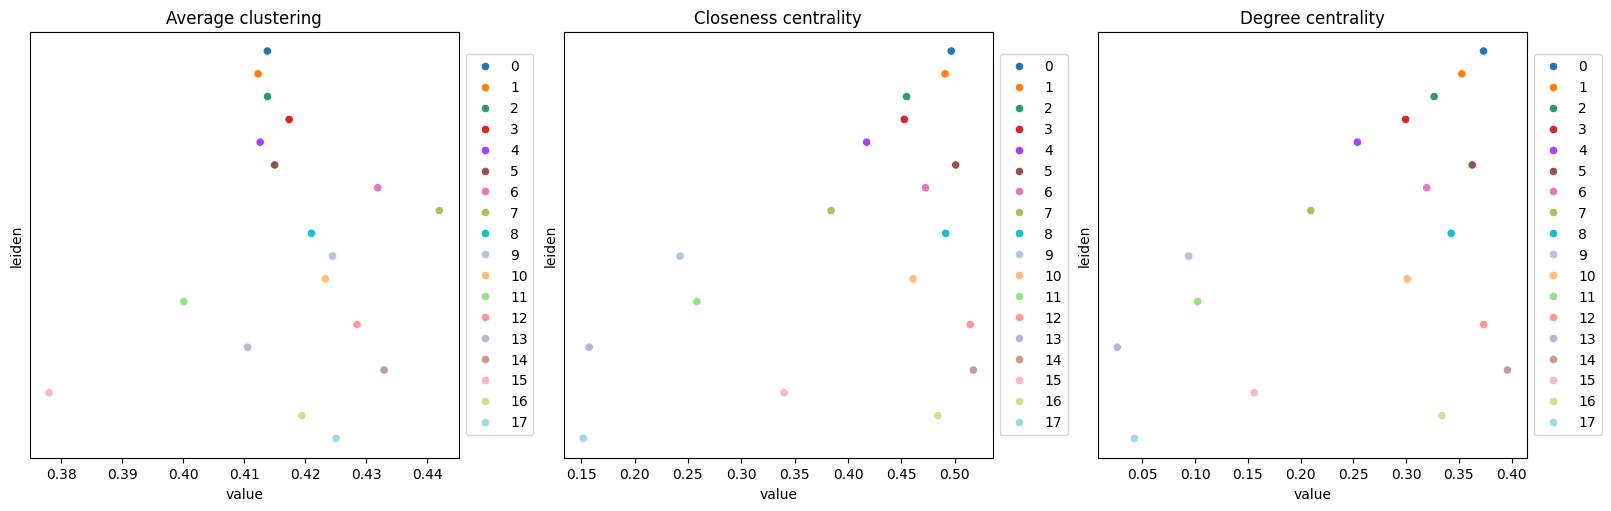

In [10]:
# Compute centrality scores for Leiden clusters
sq.gr.centrality_scores(adata, cluster_key="leiden")

# Plot degree, closeness, and average centrality
sq.pl.centrality_scores(adata, cluster_key="leiden", figsize=(16, 5))
plt.savefig("xenium_centrality_scores.png", bbox_inches="tight", dpi=300)
plt.show()

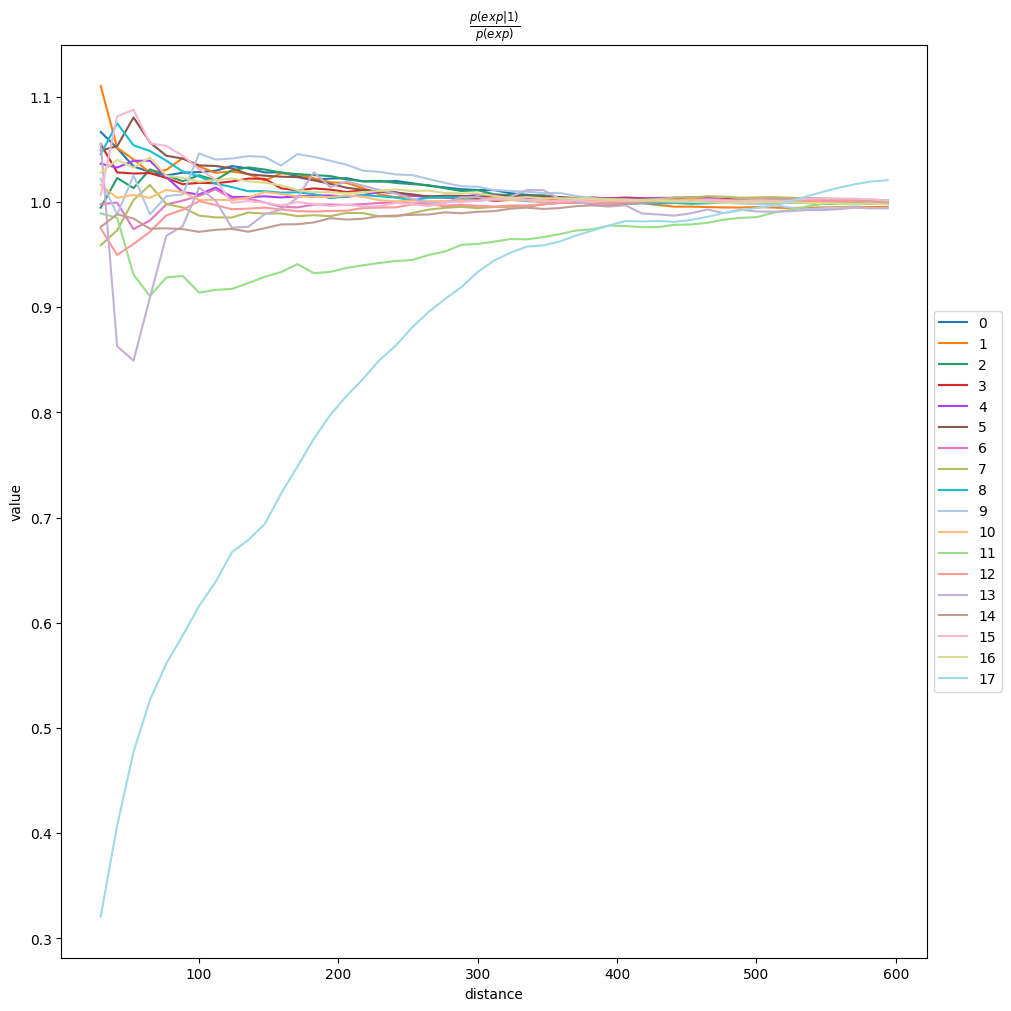

In [11]:
# Subsample data to 50% to speed up computation
sdata.tables["subsample"] = sc.pp.subsample(adata, fraction=0.5, copy=True)
adata_subsample = sdata.tables["subsample"]

# Calculate co-occurrence across distance bins
sq.gr.co_occurrence(adata_subsample, cluster_key="leiden")

# Plot spatial co-occurrence for cluster 1 against all others
sq.pl.co_occurrence(adata_subsample, cluster_key="leiden", clusters="1", figsize=(10, 10))
plt.savefig("xenium_co_occurrence.png", bbox_inches="tight", dpi=300)
plt.show()

  0%|          | 0/1000 [00:00<?, ?/s]

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


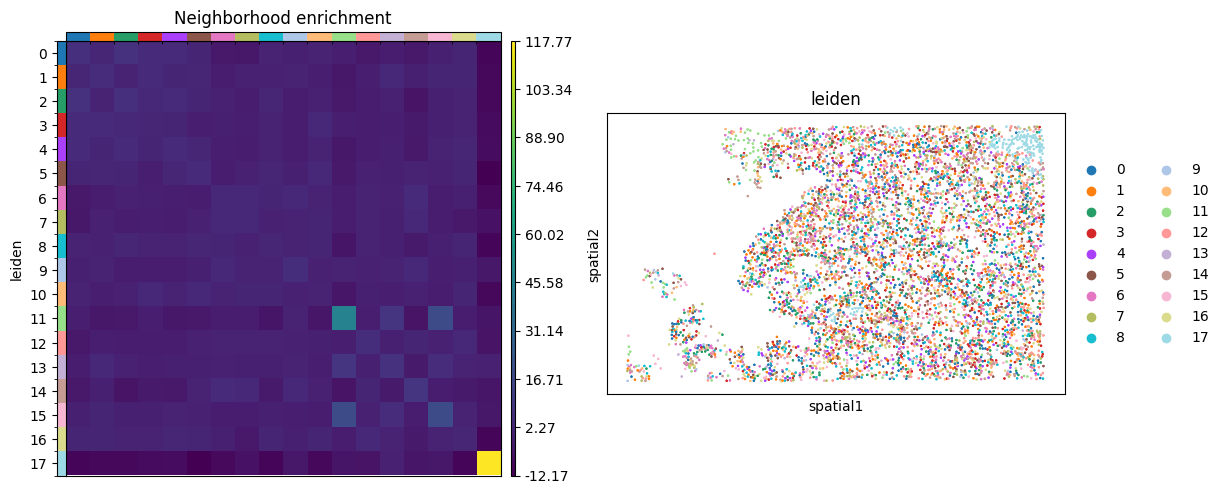

In [12]:
# Compute neighborhood enrichment scores
sq.gr.nhood_enrichment(adata, cluster_key="leiden")

# Plot enrichment heatmap and spatial scatter side-by-side
fig, ax = plt.subplots(1, 2, figsize=(13, 7))
sq.pl.nhood_enrichment(adata, cluster_key="leiden", figsize=(8, 8), title="Neighborhood enrichment", ax=ax[0])
sq.pl.spatial_scatter(adata_subsample, color="leiden", shape=None, size=2, ax=ax[1])
plt.savefig("xenium_nhood_enrichment.png", bbox_inches="tight", dpi=300)
plt.show()

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


  0%|          | 0/100 [00:00<?, ?/s]

,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
IGFBP3,0.386782,0.0,0.000057,0.0,0.009901,0.000095,0.0,0.0,0.010372
GJA5,0.367843,0.0,0.000057,0.0,0.009901,0.000060,0.0,0.0,0.010372
CXCL13,0.277089,0.0,0.000057,0.0,0.009901,0.000058,0.0,0.0,0.010372
PLA2G7,0.232207,0.0,0.000057,0.0,0.009901,0.000045,0.0,0.0,0.010372
GPX2,0.223969,0.0,0.000057,0.0,0.009901,0.000060,0.0,0.0,0.010372


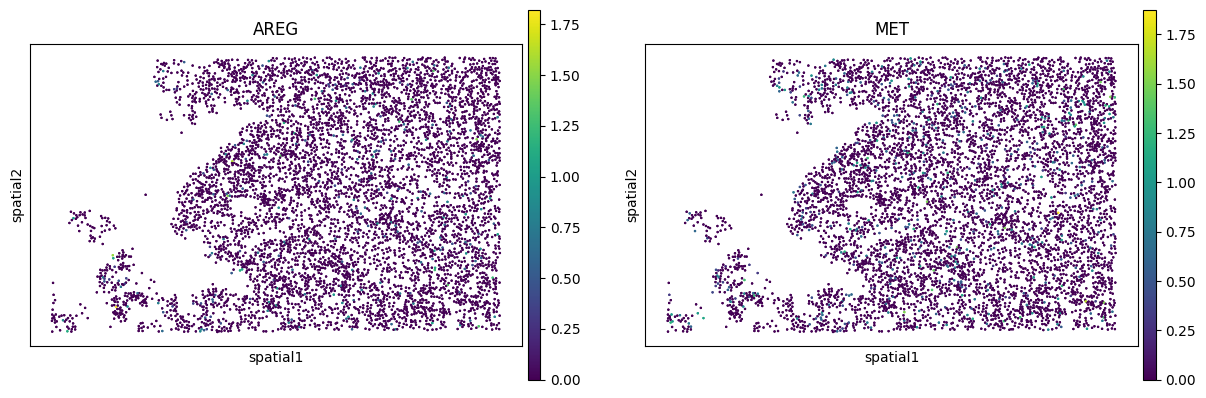

In [13]:
# Re-compute spatial graph on subsample and calculate Moran's I
sq.gr.spatial_neighbors(adata_subsample, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(adata_subsample, mode="moran", n_perms=100, n_jobs=1)

# Display top spatially variable genes
display(adata_subsample.uns["moranI"].head())

# Plot selected spatially autocorrelated genes
sq.pl.spatial_scatter(
    adata_subsample,
    library_id="spatial",
    color=["AREG", "MET"],
    shape=None,
    size=2,
    img=False
)
plt.savefig("xenium_spatial_scatter_genes.png", bbox_inches="tight", dpi=300)
plt.show()

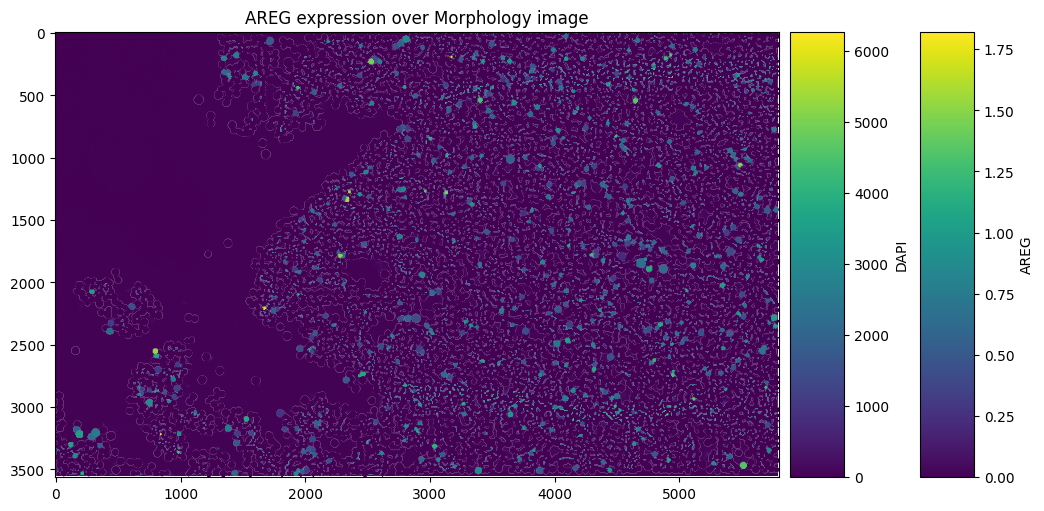

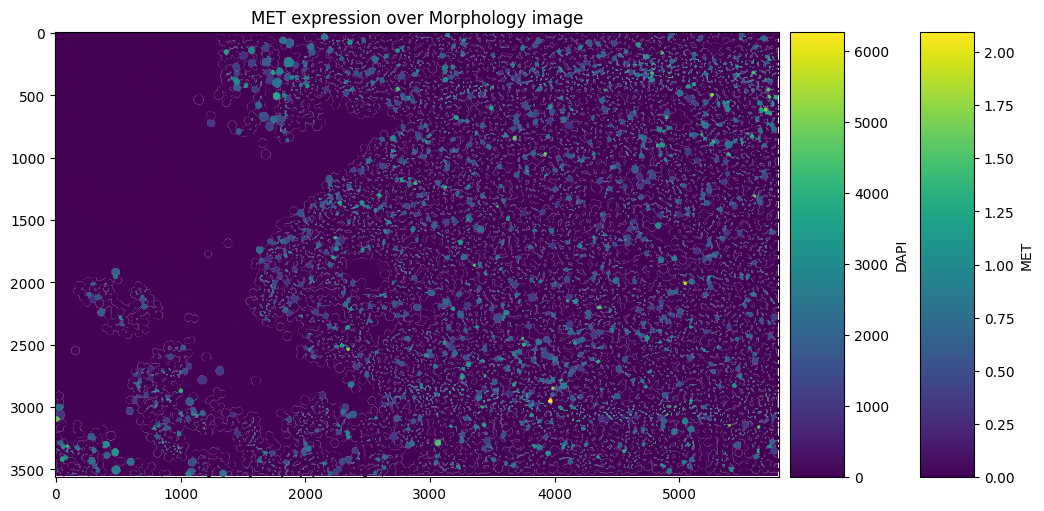

In [15]:
# Render gene expression using static spatialdata plotting
import spatialdata_plot

gene_names = ["AREG", "MET"]
for name in gene_names:
    sdata.pl.render_images("morphology_focus").pl.render_shapes(
        "cell_circles", color=name, table_name="table"
    ).pl.show(
        title=f"{name} expression over Morphology image",
        coordinate_systems="global",
        figsize=(10, 5)
    )